# 05 — Comparativa final ML vs MLP en TEST

**Caso de uso:** Predicción de Diagnóstico de Cáncer  
**Asignatura:** Inteligencia Artificial — UAX 2025/2026  
**Autor:** Álvaro Santamaría Antón

## Propósito

Aplicar todos los modelos al **conjunto de test** (no usado hasta ahora) para producir la **comparativa final**. Los resultados de este notebook son la base de las diapositivas 3, 4 y 5 del entregable.

## Reglas de evaluación

- **Modelos ML clásicos**: threshold = 0.5 (el mismo que se usó en validación)
- **MLP**: threshold = **0.68** (el optimizado en validación, **aplicado una sola vez** sobre test, siguiendo el procedimiento del PDF)
- **Test set**: 10.001 muestras × 21 features, prevalencia 19.29% (idéntica a train y val)

## Importante: data leakage prevention

El PDF marca como "error frecuente" optimizar el threshold sobre test. En este proyecto:
- El threshold óptimo (0.68) se determinó **exclusivamente en validación** (notebook 04)
- Test se usa **una única vez** y solo para la evaluación final
- Ningún modelo "ha visto" test durante entrenamiento ni durante elección de hiperparámetros

## Imports y carga

In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message=".*does not have valid feature names.*")

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.preprocessing import load_splits
from src.evaluation import (
    evaluate_model_full,
    evaluate_with_threshold,
    compare_models,
    plot_confusion_matrix,
    plot_roc_curves,
    plot_pr_curves,
    plot_metrics_comparison,
)

# Para cargar la MLP de Keras
import keras

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)

FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
MODELS_DIR  = PROJECT_ROOT / "models"

# Cargar splits
print("Cargando datos...")
data = load_splits()
X_test = data["X_test"]
y_test = data["y_test"]
print(f"  X_test: {X_test.shape}  |  positivos: {int(y_test.sum())}/{len(y_test)} ({y_test.mean()*100:.2f}%)\n")

# Cargar los 4 modelos clásicos
print("Cargando modelos clásicos...")
ml_models = {
    "Logistic Regression": joblib.load(MODELS_DIR / "logistic_regression.joblib"),
    "Random Forest":       joblib.load(MODELS_DIR / "random_forest.joblib"),
    "XGBoost":              joblib.load(MODELS_DIR / "xgboost.joblib"),
    "LightGBM":             joblib.load(MODELS_DIR / "lightgbm.joblib"),
}
for name in ml_models:
    print(f"  ✓ {name}")

# Cargar la MLP
print("\nCargando MLP...")
mlp_model = keras.models.load_model(MODELS_DIR / "mlp_cancer.keras")
mlp_results_val = joblib.load(MODELS_DIR / "mlp_results_val.joblib")
mlp_threshold = mlp_results_val["threshold_optimal"]
print(f"  ✓ MLP (threshold óptimo en val: {mlp_threshold:.2f})")

Cargando datos...
  X_test: (10001, 21)  |  positivos: 1929/10001 (19.29%)

Cargando modelos clásicos...
  ✓ Logistic Regression
  ✓ Random Forest
  ✓ XGBoost
  ✓ LightGBM

Cargando MLP...
  ✓ MLP (threshold óptimo en val: 0.68)


## Evaluación en test

In [2]:
# === Evaluación en TEST ===
print("=" * 60)
print("  EVALUACIÓN FINAL EN TEST")
print("=" * 60)

results_test = {}

# Modelos clásicos: threshold = 0.5
for name, model in ml_models.items():
    metrics = evaluate_model_full(model, X_test, y_test, threshold=0.5)
    results_test[name] = metrics
    print(f"\n  {name} (threshold = 0.5)")
    print(f"    Precisión : {metrics['precision']:.4f}")
    print(f"    Recall    : {metrics['recall']:.4f}")
    print(f"    F1-Score  : {metrics['f1']:.4f}")
    print(f"    AUC-ROC   : {metrics['auc_roc']:.4f}")
    print(f"    Accuracy  : {metrics['accuracy']:.4f}")

# MLP: threshold optimizado en validación
mlp_metrics = evaluate_model_full(mlp_model, X_test, y_test, threshold=mlp_threshold)
results_test[f"MLP (t={mlp_threshold:.2f})"] = mlp_metrics
print(f"\n  MLP (threshold = {mlp_threshold:.2f})")
print(f"    Precisión : {mlp_metrics['precision']:.4f}")
print(f"    Recall    : {mlp_metrics['recall']:.4f}")
print(f"    F1-Score  : {mlp_metrics['f1']:.4f}")
print(f"    AUC-ROC   : {mlp_metrics['auc_roc']:.4f}")
print(f"    Accuracy  : {mlp_metrics['accuracy']:.4f}")

  EVALUACIÓN FINAL EN TEST

  Logistic Regression (threshold = 0.5)
    Precisión : 0.4217
    Recall    : 0.7449
    F1-Score  : 0.5385
    AUC-ROC   : 0.8275
    Accuracy  : 0.7537

  Random Forest (threshold = 0.5)
    Precisión : 0.4341
    Recall    : 0.7278
    F1-Score  : 0.5439
    AUC-ROC   : 0.8255
    Accuracy  : 0.7645

  XGBoost (threshold = 0.5)
    Precisión : 0.4653
    Recall    : 0.5910
    F1-Score  : 0.5207
    AUC-ROC   : 0.8058
    Accuracy  : 0.7901

  LightGBM (threshold = 0.5)
    Precisión : 0.4586
    Recall    : 0.6516
    F1-Score  : 0.5383
    AUC-ROC   : 0.8156
    Accuracy  : 0.7844

  MLP (threshold = 0.68)
    Precisión : 0.5291
    Recall    : 0.5562
    F1-Score  : 0.5423
    AUC-ROC   : 0.8213
    Accuracy  : 0.8189


## Tabla comparativa final

In [3]:
# === Tabla comparativa final ===
df_final = compare_models(results_test)

print("=" * 75)
print("  RANKING FINAL EN TEST (ordenado por F1-Score)")
print("=" * 75)
display(df_final)

best_model_name = df_final.iloc[0]["Modelo"]
print(f"\n🏆 Mejor modelo en TEST: {best_model_name}")
print(f"   F1-Score: {df_final.iloc[0]['F1-Score']}")
print(f"   AUC-ROC:  {df_final.iloc[0]['AUC-ROC']}")

  RANKING FINAL EN TEST (ordenado por F1-Score)


,Modelo,Precisión,Recall,F1-Score,AUC-ROC,Accuracy,Threshold
1,Random Forest,0.4341,0.7278,0.5439,0.8255,0.7645,0.50
2,MLP (t=0.68),0.5291,0.5562,0.5423,0.8213,0.8189,0.68
3,Logistic Regression,0.4217,0.7449,0.5385,0.8275,0.7537,0.50
4,LightGBM,0.4586,0.6516,0.5383,0.8156,0.7844,0.50
5,XGBoost,0.4653,0.5910,0.5207,0.8058,0.7901,0.50



🏆 Mejor modelo en TEST: Random Forest
   F1-Score: 0.5439
   AUC-ROC:  0.8255


## Gráfico de barras de métricas

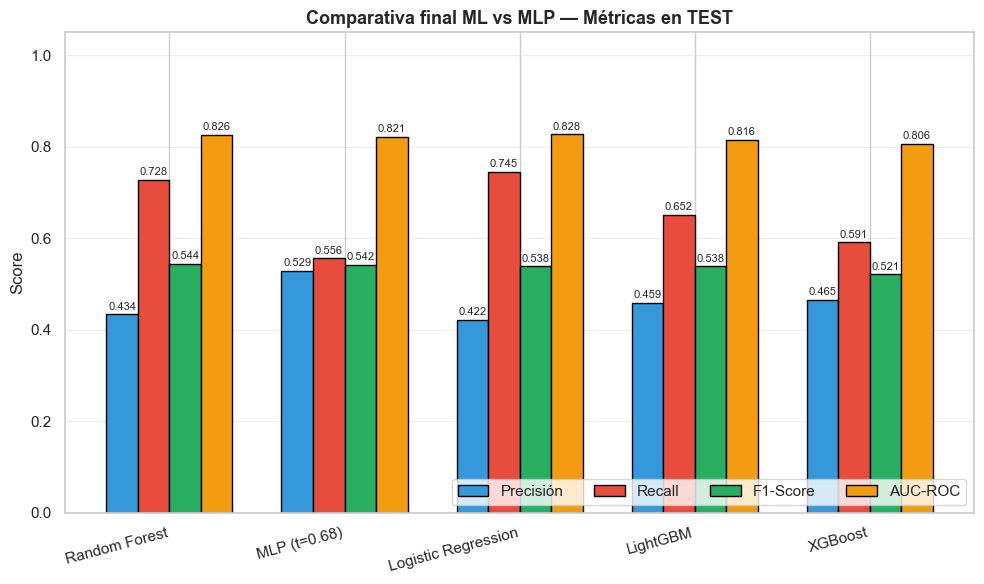

In [4]:
plot_metrics_comparison(
    df_final,
    title="Comparativa final ML vs MLP — Métricas en TEST",
    save_path=FIGURES_DIR / "19_final_metrics_comparison.png",
)
plt.show()

## Curvas ROC y PR superpuestas

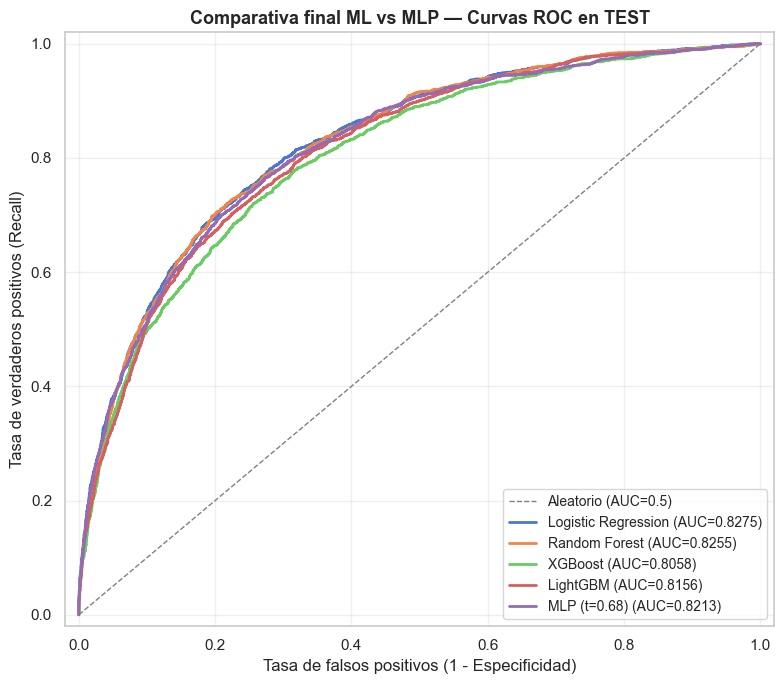

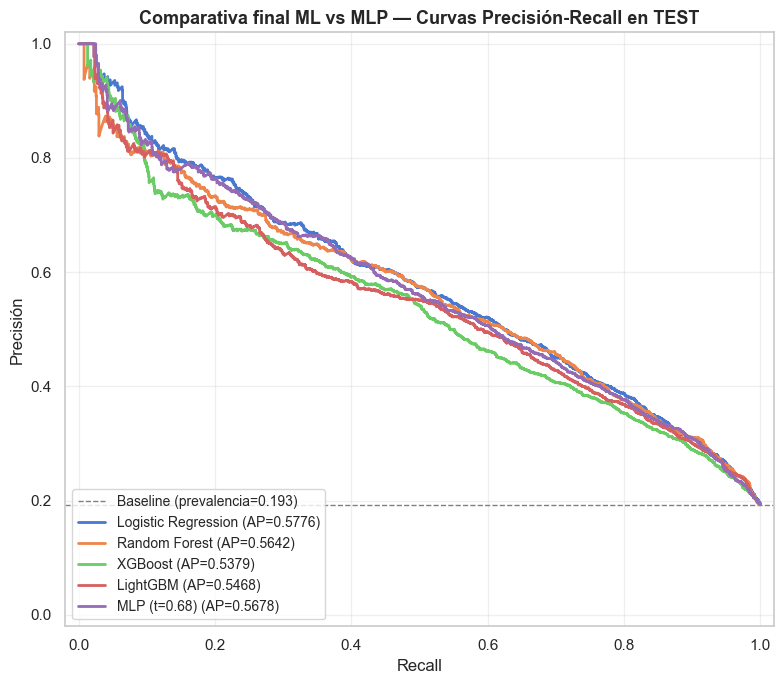

In [5]:
# === Curvas ROC ===
plot_roc_curves(
    results_test, y_test,
    title="Comparativa final ML vs MLP — Curvas ROC en TEST",
    save_path=FIGURES_DIR / "20_final_roc_curves.png",
)
plt.show()

# === Curvas Precisión-Recall ===
plot_pr_curves(
    results_test, y_test,
    title="Comparativa final ML vs MLP — Curvas Precisión-Recall en TEST",
    save_path=FIGURES_DIR / "21_final_pr_curves.png",
)
plt.show()

## Matriz de confusión del mejor modelo

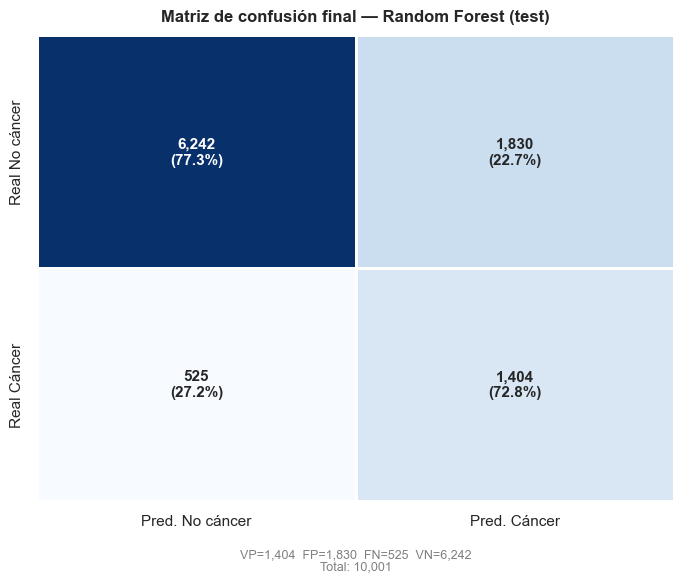


Lectura clínica de la matriz (Random Forest):
  De los 1,929 pacientes con cáncer reales en test:
    1,404 fueron detectados correctamente (recall = 72.8%)
    525 pasaron desapercibidos (falsos negativos)
  El modelo señaló a 3,234 pacientes como sospechosos:
    1,404 tenían cáncer realmente (precisión = 43.4%)
    1,830 eran falsos positivos


In [6]:
best_metrics = results_test[best_model_name]

fig, ax = plt.subplots(figsize=(7, 6))
plot_confusion_matrix(
    best_metrics["confusion_matrix"],
    title=f"Matriz de confusión final — {best_model_name} (test)",
    ax=ax,
)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "22_final_confusion_matrix.png", dpi=120, bbox_inches="tight")
plt.show()

# Análisis textual
tn, fp, fn, tp = best_metrics["confusion_matrix"].ravel()
total = tn + fp + fn + tp
recall_clinic = tp / (tp + fn) * 100
precision_clinic = tp / (tp + fp) * 100

print(f"\nLectura clínica de la matriz ({best_model_name}):")
print(f"  De los {tp+fn:,} pacientes con cáncer reales en test:")
print(f"    {tp:,} fueron detectados correctamente (recall = {recall_clinic:.1f}%)")
print(f"    {fn:,} pasaron desapercibidos (falsos negativos)")
print(f"  El modelo señaló a {tp+fp:,} pacientes como sospechosos:")
print(f"    {tp:,} tenían cáncer realmente (precisión = {precision_clinic:.1f}%)")
print(f"    {fp:,} eran falsos positivos")

## Persistencia de resultados finales

In [7]:
# === Guardar resultados finales para diapositivas ===

# Tabla a CSV (en reports/, se sube a git)
df_final.to_csv(PROJECT_ROOT / "reports" / "comparativa_final_test.csv", index=False)
print(f"Tabla comparativa guardada en: reports/comparativa_final_test.csv")

# Resultados completos a joblib (en models/, no se sube)
results_serializable = {}
for name, m in results_test.items():
    results_serializable[name] = {
        k: v for k, v in m.items() if k != "y_proba"
    }
    results_serializable[name]["y_proba_test"] = m["y_proba"]

joblib.dump(results_serializable, MODELS_DIR / "results_final_test.joblib")
print(f"Resultados completos guardados en: models/results_final_test.joblib")

print("\n" + "=" * 60)
print("  FASE 6 COMPLETADA")
print("=" * 60)
print(f"  ✓ 5 modelos evaluados en test (10.001 pacientes nunca vistos)")
print(f"  ✓ Mejor modelo: {best_model_name}")
print(f"  ✓ 4 figuras nuevas generadas (19-22)")
print(f"\n  Listo para producir las 5 diapositivas (Fase 7).")

Tabla comparativa guardada en: reports/comparativa_final_test.csv
Resultados completos guardados en: models/results_final_test.joblib

  FASE 6 COMPLETADA
  ✓ 5 modelos evaluados en test (10.001 pacientes nunca vistos)
  ✓ Mejor modelo: Random Forest
  ✓ 4 figuras nuevas generadas (19-22)

  Listo para producir las 5 diapositivas (Fase 7).
